# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")

In [3]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-09 13:19:04--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.007s  

2026-05-09 13:19:04 (10.7 MB/s) - ‘wineqr.csv’ saved [84143/84143]



In [7]:
# Загрузите данные, удалите столбец quality, выполните масштабирование (StandardScaler).
df = pd.read_csv('wineqr.csv')
X = df.drop('quality', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
#Для K от 2 до 10:
    # Обучите K‑Means
    # Вычислите WCSS и коэффициент силуэта

K_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
for k, w, s in zip(K_range, wcss, silhouette_scores):
    print(f"K={k}: WCSS={w:.2f}, Silhouette={s:.4f}")

K=2: WCSS=14330.12, Silhouette=0.2137
K=3: WCSS=12629.97, Silhouette=0.1892
K=4: WCSS=11459.14, Silhouette=0.1716
K=5: WCSS=10155.51, Silhouette=0.1901
K=6: WCSS=9363.21, Silhouette=0.1947
K=7: WCSS=8645.20, Silhouette=0.1926
K=8: WCSS=8298.97, Silhouette=0.1495
K=9: WCSS=7969.34, Silhouette=0.1534
K=10: WCSS=7671.02, Silhouette=0.1574


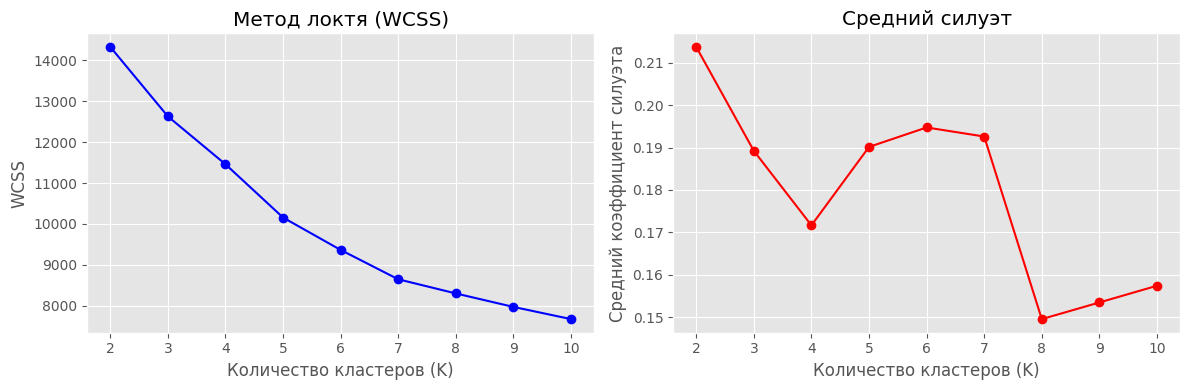

In [10]:
# Постройте два графика: метод локтя (WCSS) и средний силуэт.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# WCSS
ax1.plot(K_range, wcss, 'bo-')
ax1.set_xlabel('Количество кластеров (K)')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (WCSS)')
ax1.grid(True)

# средний силуэт
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров (K)')
ax2.set_ylabel('Средний коэффициент силуэта')
ax2.set_title('Средний силуэт')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Выберите оптимальное K по силуэту.
# Оптимальное K соответствует максимальному значению среднего коэффициента силуэта.
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по силуэту: {optimal_k}")

Оптимальное количество кластеров по силуэту: 2


In [12]:
# Обучите финальную модель K‑Means с выбранным K.
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(X_scaled)

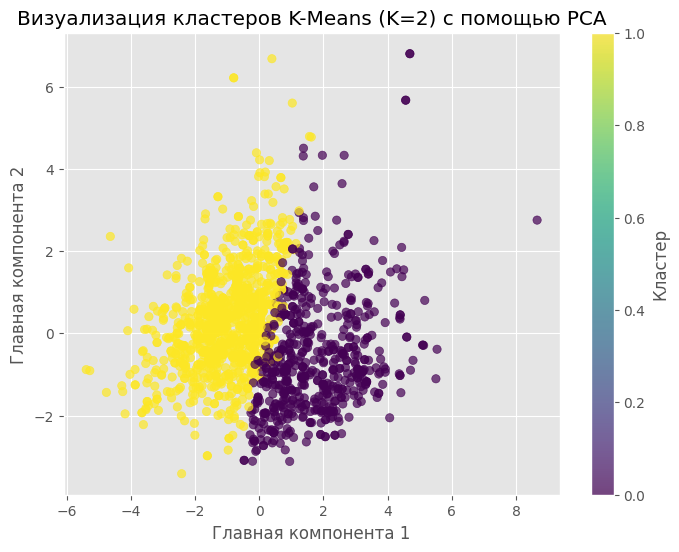

In [14]:
# С помощью PCA (2 компоненты) визуализируйте кластеры.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.title(f'Визуализация кластеров K-Means (K={optimal_k}) с помощью PCA')
plt.grid(True)
plt.show()

In [15]:
# Выведите силуэт финальной модели.
final_silhouette = silhouette_score(X_scaled, final_labels)
print(f"Средний коэффициент силуэта для финальной модели (K={optimal_k}): {final_silhouette:.4f}")

Средний коэффициент силуэта для финальной модели (K=2): 0.2137


## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

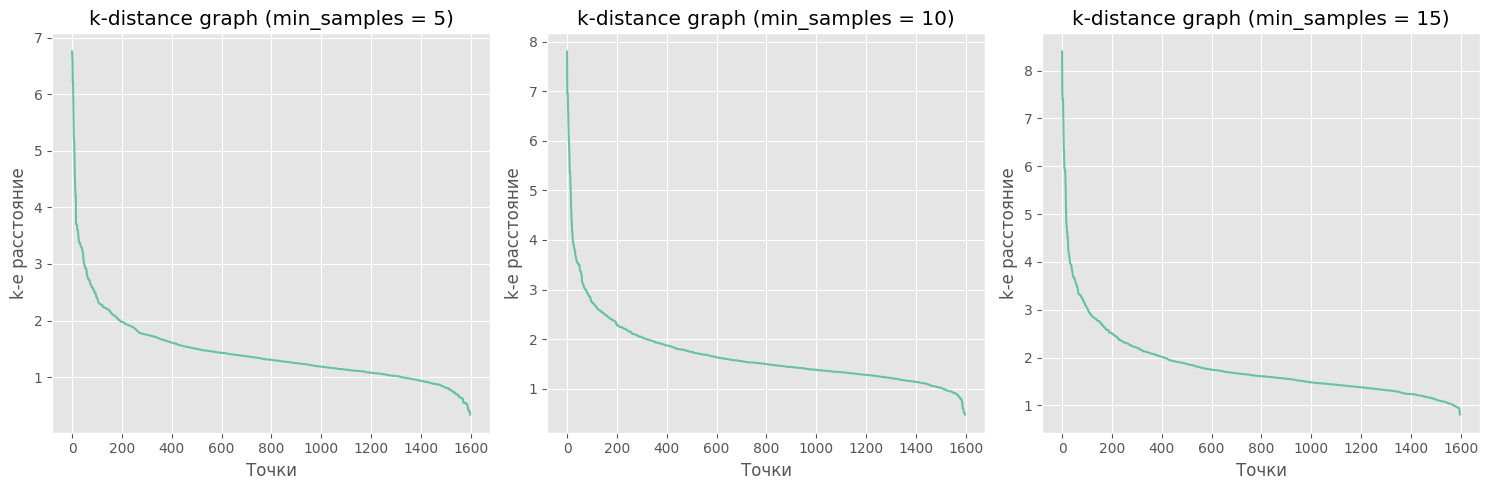

In [16]:
# Постройте k‑distance graph для min_samples = 5, 10, 15.

def plot_k_distance_graph(X, min_samples_list):
    fig, axes = plt.subplots(1, len(min_samples_list), figsize=(15, 5))
    for idx, k in enumerate(min_samples_list):
        from sklearn.neighbors import NearestNeighbors
        neigh = NearestNeighbors(n_neighbors=k)
        neigh.fit(X)
        distances, _ = neigh.kneighbors(X)
        k_dist = np.sort(distances[:, -1])[::-1]

        axes[idx].plot(k_dist)
        axes[idx].set_title(f'k-distance graph (min_samples = {k})')
        axes[idx].set_xlabel('Точки')
        axes[idx].set_ylabel('k-е расстояние')
        axes[idx].grid(True)
    plt.tight_layout()
    plt.show()
plot_k_distance_graph(X_scaled, [5, 10, 15])

In [17]:
# Методом перебора (eps от 0.3 до 1.1 с шагом 0.1, min_samples = 5, 10, 15) найдите параметры, дающие максимальный силуэт (число кластеров ≥ 2, шум не более 80% данных).

eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_values = [5, 10, 15]

best_score = -1
best_params = None
best_labels = None

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)
        noise_ratio = n_noise / len(labels)
        if n_clusters >= 2 and noise_ratio <= 0.8 and n_clusters != len(X_scaled):
            mask = labels != -1
            if mask.sum() > 0:
                score = silhouette_score(X_scaled[mask], labels[mask])
                if score > best_score:
                    best_score = score
                    best_params = (eps, ms)
                    best_labels = labels
                    print(f"eps={eps:.1f}, min_samples={ms}: кластеров={n_clusters}, шума={noise_ratio:.2%}, силуэт={score:.4f}")

print(f"\nЛучшие параметры: eps={best_params[0]:.1f}, min_samples={best_params[1]}")
print(f"Силуэт (без шума): {best_score:.4f}")

eps=1.0, min_samples=5: кластеров=24, шума=72.86%, силуэт=0.1300
eps=1.1, min_samples=10: кластеров=7, шума=77.17%, силуэт=0.2456

Лучшие параметры: eps=1.1, min_samples=10
Силуэт (без шума): 0.2456


In [19]:
# Обучите DBSCAN с лучшими параметрами.

dbscan_best = DBSCAN(eps=best_params[0], min_samples=best_params[1])
best_labels = dbscan_best.fit_predict(X_scaled)

n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = sum(best_labels == -1)

print(f"  Параметры: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"  Количество кластеров: {n_clusters}")
print(f"  Шумовые точки: {n_noise} ({n_noise/len(X_scaled):.2%})")

  Параметры: eps=1.1000000000000003, min_samples=10
  Количество кластеров: 7
  Шумовые точки: 1234 (77.17%)


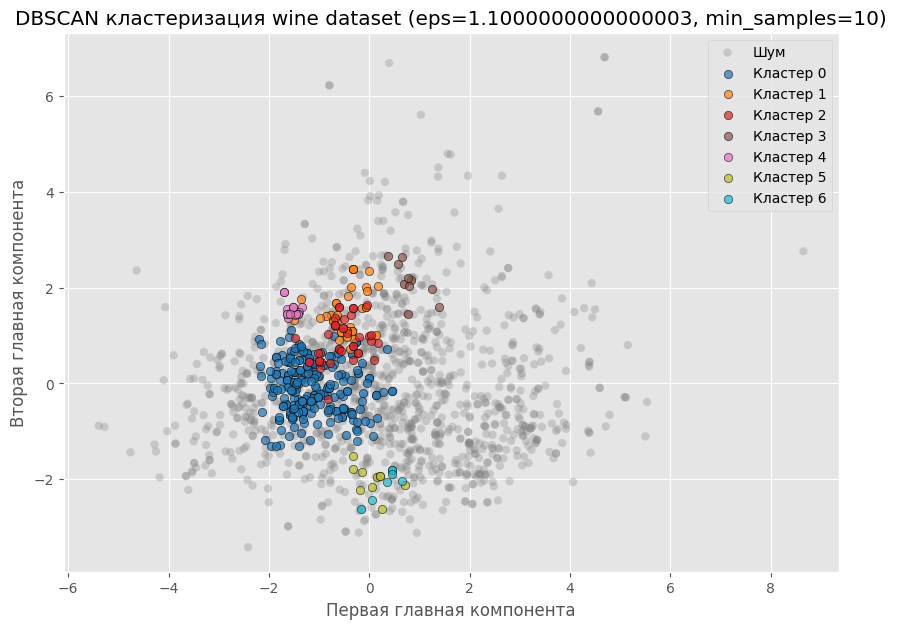

In [20]:
# Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
noise_mask = best_labels == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='gray', label='Шум', alpha=0.3, edgecolors='none')

unique_labels = set(best_labels) - {-1}
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    mask = best_labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[col], label=f'Кластер {k}', alpha=0.7, edgecolors='k')

plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title(f'DBSCAN кластеризация wine dataset (eps={best_params[0]}, min_samples={best_params[1]})')
plt.legend()
plt.grid(True)
plt.show()

5. **Ответьте на вопросы (письменно):**
-  Почему для DBSCAN критически важно масштабировать данные?

DBSCAN основан на расстояниях между точками (обычно используется евклидово расстояние). Если признаки имеют разные масштабы, признаки с большими числовыми значениями будут доминировать, и алгоритм выделит искусственные кластеры, не отражающие реальную структуру данных. Масштабирование (например, StandardScaler) приводит все признаки к сопоставимому диапазону.

- Что будет при слишком маленьком `eps`? Слишком большом?

При слишком маленьком eps каждая точка будет считать своим соседом только очень близкие точки. Количество кластеров увеличится, количество шумовых точек также возрастёт — многие точки могут оказаться изолированными. В пределе (при стремлении eps к нулю) каждая точка станет собственным кластером.

При слишком большом eps область радиуса eps охватит слишком много точек, и различные скопления сольются в один кластер. В крайнем случае все точки будут отнесены к одному кластеру (или почти все, если используется min_samples).

- Что означают точки с меткой `-1`?

Это шумовые точки (outliers). Они не принадлежат ни к одному кластеру, поскольку находятся в областях пониженной плотности и не имеют достаточного количества соседей в пределах радиуса eps.

- Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

K‑Means предполагает, что кластеры имеют сферическую форму и одинаковый радиус, и стремится минимизировать внутрикластерную дисперсию. Все точки обязательно относятся к какому-либо кластеру.

DBSCAN не накладывает ограничений на форму кластеров и может выделять произвольные скопления точек, основанные на плотности. Он автоматически определяет количество кластеров и допускает наличие шума.

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

In [24]:
# Обучите OPTICS на тех же данных с параметрами:

  # min_samples = 10
  # xi = 0.05
  # min_cluster_size = 0.05


from sklearn.cluster import OPTICS
import time
optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)

In [34]:
# Выведите:

  # количество найденных кластеров
  # количество шумовых точек
  # коэффициент силуэта

start_time = time.time()
optics_labels = optics_model.fit_predict(X_scaled)
end_time = time.time()

n_clusters = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise = sum(optics_labels == -1)

print(f"Найденные кластеры (без шума): {n_clusters}")
print(f"Шумовые точки (метка -1): {n_noise}")

if n_clusters >= 2:
    mask = optics_labels != -1
    sil_score = silhouette_score(X_scaled[mask], optics_labels[mask])
    print(f"Коэффициент силуэта:          {sil_score:.4f}")
else:
    print(f"Коэффициент силуэта не вычисляется (найден только 1 кластер)")

print(f"Время обучения OPTICS: {end_time - start_time:.4f} секунд")

Найденные кластеры (без шума): 1
Шумовые точки (метка -1): 0
Коэффициент силуэта не вычисляется (найден только 1 кластер)
Время обучения OPTICS: 4.5124 секунд


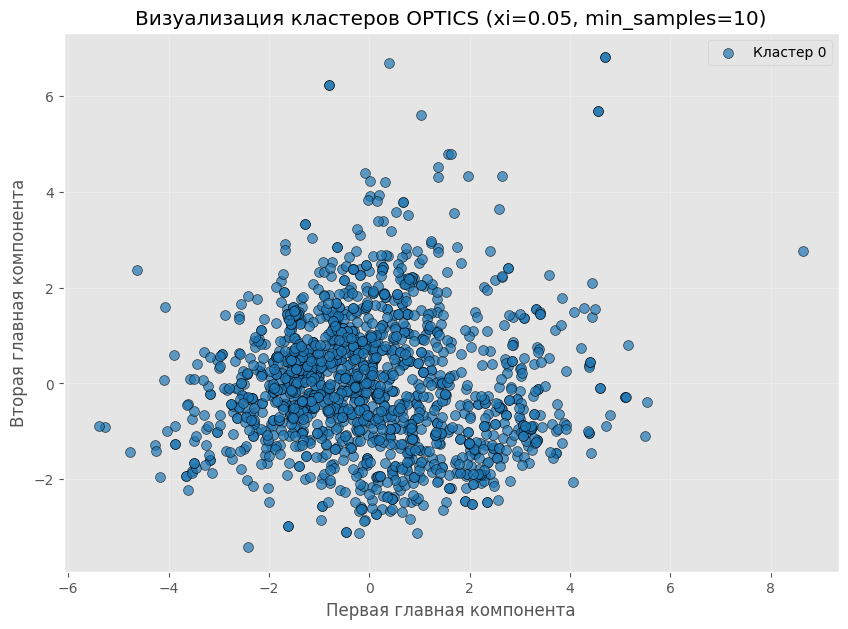

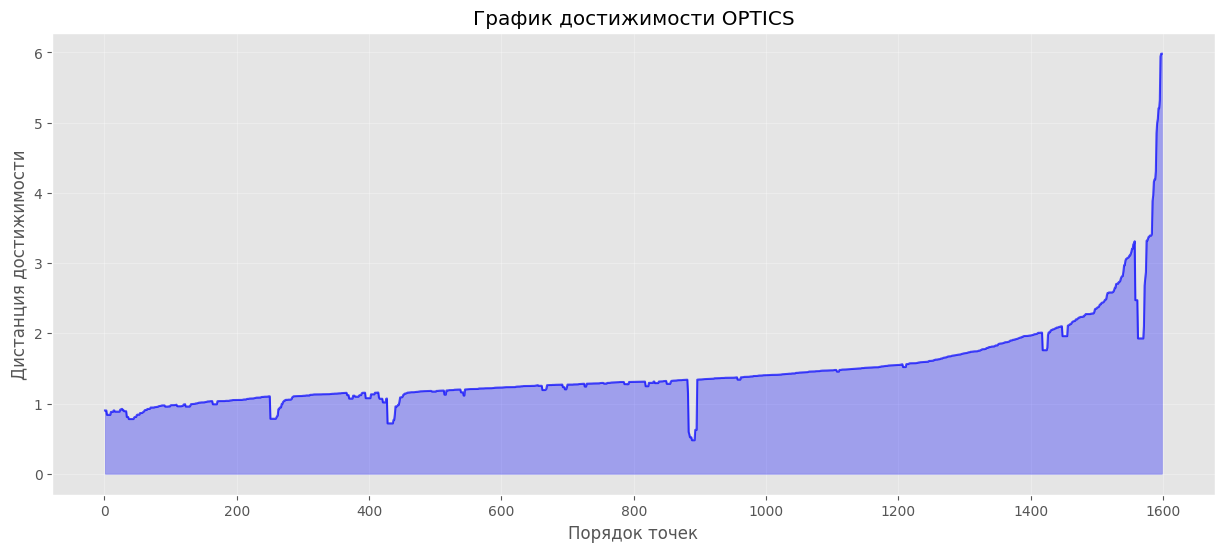

In [31]:
#Постройте:

   # визуализацию кластеров через PCA
   # reachability plot (график достижимости)

plt.figure(figsize=(10, 7))
unique_labels = set(optics_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'gray'
        label = 'Шум'
    else:
        label = f'Кластер {k}'
    mask = optics_labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[col], label=label, alpha=0.7, edgecolors='k', s=50)

plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title(f'Визуализация кластеров OPTICS (xi=0.05, min_samples=10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ordering = optics_model.ordering_
reachability = optics_model.reachability_[ordering]

plt.figure(figsize=(15, 6))
plt.plot(reachability, 'b-', alpha=0.7)
plt.fill_between(range(len(reachability)), reachability, color='blue', alpha=0.3)
plt.title('График достижимости OPTICS')
plt.xlabel('Порядок точек')
plt.ylabel('Дистанция достижимости')
plt.grid(True, alpha=0.3)


1. Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.

Ключевое отличие заключается в работе с кластерами переменной плотности и в самой структуре результата.

Во-первых, в то время как DBSCAN использует глобальный параметр eps, OPTICS сохраняет иерархию кластеров для переменного радиуса окрестности. Это позволяет алгоритму выделять кластеры с различной плотностью в одном наборе данных, что является его главным преимуществом перед DBSCAN.

Во-вторых, OPTICS не просто присваивает точкам метки, а создает общий порядок точек и вычисляет для них дистанции достижимости. Эта информация визуализируется на графике достижимости, где провалы соответствуют кластерам, а пики — границам между ними. По сути, этот график представляет собой компактное иерархическое представление кластерной структуры данных.

2. Что такое параметр xi (кси) и как он влияет на выделение кластеров?

Он определяет, как из графика достижимости будут выделены финальные кластеры.
Параметр xi задает minimum steepness на графике достижимости, которая необходима для определения границы кластера.
Также он определяет, какие провалы в данных считать отдельными кластерами, а какие — частью более крупного. Меньшее значение xi сделает алгоритм более чувствительным, выделяя более мелкие и детальные кластеры. Фактически, этот метод позволяет алгоритму OPTICS восстанавливать иерархическую структуру кластеров, извлекая их автоматически на основе заранее заданного порога крутизны склона на графике достижимости.